# FastText Spam Classifier — Train & Test

Notebook thử nghiệm train model **FastText supervised** trên CPU để lọc spam/bot tweet crypto.

**Dataset:** [`sandiumenge/bitcoin-tweets-spam-emotion-sentiment`](https://huggingface.co/datasets/sandiumenge/bitcoin-tweets-spam-emotion-sentiment)

| Label gốc | FastText label |
|-----------|----------------|
| `human`   | `human`        |
| `spam`, `bot` | `spam`     |

Chạy từ thư mục project:
```bash
cd playground/finetune/fasttext
uv sync --group dev
uv run jupyter notebook notebooks/train_and_test.ipynb
```

## 1. Setup paths & imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODEL_DIR / "spam_model.bin"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

PROJECT_ROOT: /home/adc300/src/ptit/hqtcsdl_btl_new/playground/finetune/fasttext
DATA_DIR: /home/adc300/src/ptit/hqtcsdl_btl_new/playground/finetune/fasttext/data
MODEL_DIR: /home/adc300/src/ptit/hqtcsdl_btl_new/playground/finetune/fasttext/models


In [2]:
import fasttext
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset

from lib.data import DATASET_ID, export_all, map_label, normalize_text, sample_lines
from lib.train import (
    confusion_matrix_from_file,
    evaluate_on_file,
    predict_text,
    train_model,
)

print("fasttext version:", fasttext.__version__ if hasattr(fasttext, "__version__") else "ok")

fasttext version: ok


## 2. Load & explore dataset

In [3]:
ds = load_dataset(DATASET_ID)
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'spam', 'emotion', 'sentiment'],
        num_rows: 76452
    })
    validation: Dataset({
        features: ['text', 'spam', 'emotion', 'sentiment'],
        num_rows: 16383
    })
    test: Dataset({
        features: ['text', 'spam', 'emotion', 'sentiment'],
        num_rows: 16383
    })
})

In [4]:
train_df = ds["train"].to_pandas()
train_df["ft_label"] = train_df["spam"].map(map_label)

label_counts = train_df["ft_label"].value_counts()
print(label_counts)
print(f"\nTotal train rows: {len(train_df):,}")

train_df[["text", "spam", "ft_label"]].head(3)

ft_label
human    40402
spam     36050
Name: count, dtype: int64

Total train rows: 76,452


,text,spam,ft_label
0,Crypto Ads to be Screened in the Philippines f...,bot,spam
1,"@Bitcoin Choose the second one, how do you feel?",human,human
2,Bitcoin is the best thing to happen to @tradin...,human,human


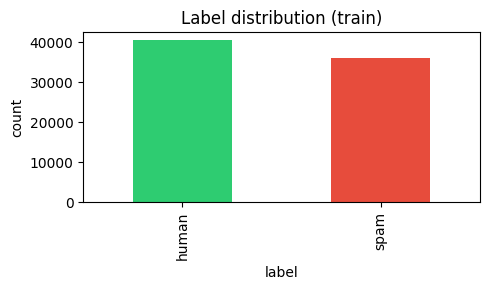

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
label_counts.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"])
ax.set_title("Label distribution (train)")
ax.set_xlabel("label")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 3. Export FastText format

Mỗi dòng: `__label__<class> <text>`

In [6]:
stats = export_all(DATA_DIR)
stats

{'train': 76452, 'validation': 16383, 'test': 16383}

In [7]:
print("Sample train lines:")
for line in sample_lines(DATA_DIR / "train.txt", n=3):
    print(line[:120] + ("..." if len(line) > 120 else ""))

Sample train lines:
__label__spam Crypto Ads to be Screened in the Philippines from 7 July - Regulation Asia https://t.co/2w6iZeO2y9 via @re...
__label__human @Bitcoin Choose the second one, how do you feel?
__label__human Bitcoin is the best thing to happen to @tradingview


## 4. Train model (CPU)

Hyperparams mặc định phù hợp CPU — train ~5–15 phút tùy máy.

In [9]:
TRAIN_CONFIG = {
    "dim": 100,
    "epoch": 25,
    "lr": 0.5,
    "word_ngrams": 2,
    "min_count": 1,
    "loss": "softmax",
}
TRAIN_CONFIG

{'dim': 100,
 'epoch': 25,
 'lr': 0.5,
 'word_ngrams': 2,
 'min_count': 1,
 'loss': 'softmax'}

In [10]:
model = train_model(
    DATA_DIR / "train.txt",
    MODEL_DIR,
    model_name="spam_model",
    **TRAIN_CONFIG,
)
print("Saved:", MODEL_PATH)

Read 2M words
Number of words:  256195
Number of labels: 2
Progress: 100.0% words/sec/thread:  782068 lr:  0.000000 avg.loss:  0.028173 ETA:   0h 0m 0s


Saved: /home/adc300/src/ptit/hqtcsdl_btl_new/playground/finetune/fasttext/models/spam_model.bin


## 5. Evaluate on test set

In [11]:
metrics, summary = evaluate_on_file(model, DATA_DIR / "test.txt")
print(summary)
metrics

samples=16383  precision=0.8613  recall=0.8613

              precision    recall  f1-score   support

       human     0.8688    0.8699    0.8694      8695
        spam     0.8527    0.8515    0.8521      7688

    accuracy                         0.8613     16383
   macro avg     0.8608    0.8607    0.8607     16383
weighted avg     0.8612    0.8613    0.8613     16383



{'samples': 16383,
 'precision': 0.8612586217420497,
 'recall': 0.8612586217420497}

In [12]:
labels, matrix = confusion_matrix_from_file(model, DATA_DIR / "test.txt")
cm_df = pd.DataFrame(matrix, index=[f"true_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
cm_df

,pred_human,pred_spam
true_human,7564,1131
true_spam,1142,6546


## 6. Interactive inference — thử tay

In [13]:
SAMPLE_TWEETS = [
    "Bitcoin ETF approval could bring massive institutional inflows this quarter.",
    "Join our Telegram for 100x gains! Free airdrop DM me now https://t.co/abc",
    "I am claiming my free Lightning sats from amazing faucet! #Bitcoin #Airdrop",
    "$BTC rejected at resistance, watching $43k support level.",
    "WE ARE READY - IDO ON TUESDAY #crypto #bitcoin #airdrop #100x",
]

rows = []
for text in SAMPLE_TWEETS:
    label, score = predict_text(model, normalize_text(text))
    rows.append({"text": text, "label": label, "confidence": round(score, 4)})

pd.DataFrame(rows)

,text,label,confidence
0,Bitcoin ETF approval could bring massive insti...,human,0.9335
1,Join our Telegram for 100x gains! Free airdrop...,spam,1.0000
2,I am claiming my free Lightning sats from amaz...,spam,1.0000
3,"$BTC rejected at resistance, watching $43k sup...",human,0.8415
4,WE ARE READY - IDO ON TUESDAY #crypto #bitcoin...,spam,1.0000


## 7. (Optional) Test trên X-API output

Nếu đã chạy `playground/X-API/run.py`, load `search_results.json` và classify.

In [14]:
import json

X_API_JSON = PROJECT_ROOT.parent.parent / "X-API" / "search_results.json"

if X_API_JSON.exists():
    with X_API_JSON.open(encoding="utf-8") as f:
        payload = json.load(f)
    tweets = payload.get("tweets") or payload.get("results") or payload
    if isinstance(tweets, list) and tweets:
        x_rows = []
        for t in tweets[:20]:
            text = t.get("text") or ""
            label, score = predict_text(model, normalize_text(text))
            x_rows.append({
                "user": t.get("user"),
                "label": label,
                "confidence": round(score, 4),
                "text": text[:100] + ("..." if len(text) > 100 else ""),
            })
        display(pd.DataFrame(x_rows))
    else:
        print("JSON found but no tweet list — check schema.")
else:
    print(f"Skip: {X_API_JSON} not found. Run X-API playground first.")

,user,label,confidence,text
0,BitcoinNewsCom,human,0.9656,🇿🇦 SOUTH AFRICA PROPOSES INSANE CRYPTO CONTROL...
1,BitcoinMagazine,human,1.0000,JUST IN: 🇺🇸 White House Executive Director Pat...
2,CoinMarketCap,human,0.9978,LATEST: 🇺🇸 Rep. Nick Begich says he plans to r...
3,BitcoinMagazine,human,0.9549,JUST IN: 🇺🇸 White House Executive Director say...
4,CryptoNobler,human,0.8891,🚨 BREAKING\n\n🇺🇸 FED WILL OFFICIALLY ANNOUNCE ...
5,coinbureau,spam,0.9925,🚨 BREAKING: BITCOIN JUST FLASH CRASHED TO $77....
6,BankXRP,spam,0.9999,Big moves for @Coinbase Derivatives! They've j...
7,AshCrypto,spam,0.9482,"$BTC dropped below $77,000\n\n$ETH dropped bel..."
8,TedPillows,spam,0.8019,"$ETH ETF outflow of $50,400,000 🔴 yesterday.\n..."
9,AshCrypto,spam,0.9972,BREAKING:\n\n🇰🇷 South Korean stock market just...


## 8. Load saved model (lần chạy sau)

Bỏ qua train nếu đã có `models/spam_model.bin`.

In [15]:
if MODEL_PATH.exists():
    loaded = fasttext.load_model(str(MODEL_PATH))
    label, score = predict_text(loaded, "Buy BTC now to the moon!")
    print(f"Reload OK → {label} ({score:.4f})")
else:
    print("Model not found — run train cell first.")

Reload OK → human (0.9998)
